# COVID-19 Vaccination Data Analysis

This project analyzes global COVID-19 vaccination trends and visualizes them using:

- Time series analysis  
- Geographic mapping (Folium)  

## Objective

- Analyze vaccination trends over time  
- Compare vaccination progress across countries  
- Visualize global vaccination distribution  

## Tools Used
- Python
- Pandas
- Matplotlib
- Folium

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import folium

## Data Loading

In [ ]:
df=pd.read_csv('/Users/Chanchalpereira/Downloads/VS Code/samsung-innovation-campus-2026/samsung-innovation-campus-2026/chapter-8-mini-projects/covid-vaccination-doses-per-capita.csv')
df.head()

,Entity,Code,Day,total_vaccinations_per_hundred
0,Afghanistan,AFG,2021-02-22,0.00
1,Afghanistan,AFG,2021-02-28,0.02
2,Afghanistan,AFG,2021-03-16,0.14
3,Afghanistan,AFG,2021-04-07,0.31
4,Afghanistan,AFG,2021-04-22,0.62


## Dataset Overview

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Entity                          15854 non-null  str    
 1   Code                            13395 non-null  str    
 2   Day                             15854 non-null  str    
 3   total_vaccinations_per_hundred  15854 non-null  float64
dtypes: float64(1), str(3)
memory usage: 823.3 KB


In [49]:
df.describe()

,total_vaccinations_per_hundred
count,15854.000000
mean,21.574315
std,28.609496
min,0.000000
25%,1.910000
50%,9.515000
75%,30.097500
max,231.010000


In [50]:
df.isnull().sum()  

Entity                               0
Code                              2459
Day                                  0
total_vaccinations_per_hundred       0
dtype: int64

## Data Cleaning

- Convert date column  
- Sort data  
- Filter for country-level analysis  

In [3]:
df['Day'] = pd.to_datetime(df['Day'])
df = df.sort_values(by='Day')

country = "India"
df_country = df[df['Entity'] == country]

df_country = df_country.set_index('Day')

df_country.head()

,Entity,Code,total_vaccinations_per_hundred
Day,,,
2021-01-15,India,IND,0.00
2021-01-16,India,IND,0.01
2021-01-17,India,IND,0.02
2021-01-18,India,IND,0.03
2021-01-19,India,IND,0.05


## Vaccination Trend (India)

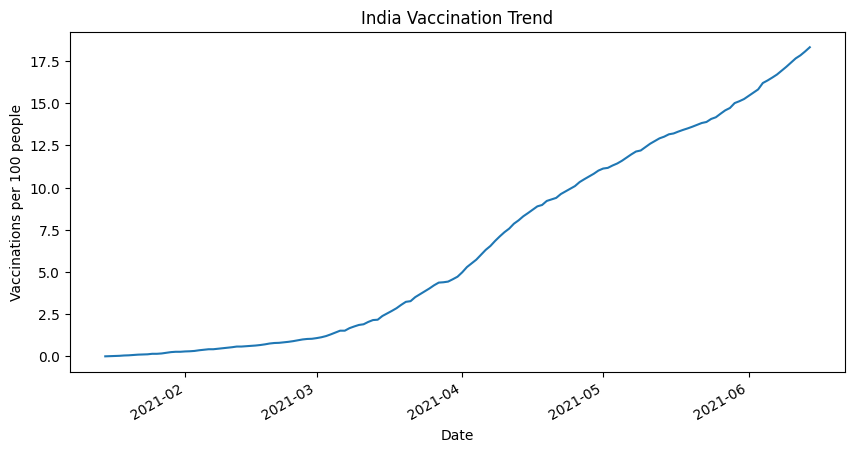

In [4]:
df_country['total_vaccinations_per_hundred'].plot(
    figsize=(10,5),
    title="India Vaccination Trend"
)
plt.xlabel("Date")
plt.ylabel("Vaccinations per 100 people")
plt.show()

## Global Map Visualization

In [5]:
df_latest = df.sort_values('Day').groupby('Entity').tail(1)

map_data = df_latest[['Entity', 'total_vaccinations_per_hundred']]

map_data.head()

,Entity,total_vaccinations_per_hundred
14307,Turkmenistan,0.70
1843,Bonaire Sint Eustatius and Saba,28.19
4760,Falkland Islands,126.53
11923,Saint Helena,130.00
11917,Rwanda,3.09


## Mapping Vaccination Levels

In [ ]:
API_KEY = "YOUR_API_KEY"

tile_url = f"https://tiles.stadiamaps.com/tiles/stamen_watercolor/{{z}}/{{x}}/{{y}}.jpg?api_key={API_KEY}"

attribution = '&copy; <a href="https://stadiamaps.com">Stadia Maps</a> &copy; <a href="http://stamen.com">Stamen Design</a>'

map = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles=tile_url,
    attr=attribution
)

map

folium.Marker(
    location=[28.6139, 77.2090],
    popup="India",
    tooltip="Vaccination Data"
).add_to(map)

map

In [ ]:
map = folium.Map(location=[20, 0], zoom_start=2)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri"
).add_to(map)

folium.Marker(
    location=[22.90581592585081, 79.47688587593206],
    popup="India",
    tooltip="Vaccination Data"
).add_to(map)

display(map)

### Mapping Vaccination Data

The latest vaccination value for each country is extracted and plotted using circle markers.

- Marker size represents vaccination percentage
- Color indicates level of vaccination progress

This provides a geographic perspective on vaccination trends.

In [56]:
df_latest = df.sort_values('Day').groupby('Entity').tail(1)

df_latest.head()

,Entity,Code,Day,total_vaccinations_per_hundred
14307,Turkmenistan,TKM,2021-04-04,0.70
1843,Bonaire Sint Eustatius and Saba,BES,2021-04-09,28.19
4760,Falkland Islands,FLK,2021-04-14,126.53
11923,Saint Helena,SHN,2021-05-05,130.00
11917,Rwanda,RWA,2021-05-08,3.09


In [57]:
map_data = df_latest[['Entity', 'total_vaccinations_per_hundred']]
map_data.head()

,Entity,total_vaccinations_per_hundred
14307,Turkmenistan,0.70
1843,Bonaire Sint Eustatius and Saba,28.19
4760,Falkland Islands,126.53
11923,Saint Helena,130.00
11917,Rwanda,3.09


In [58]:
coords = {
    "India": [28.6139, 77.2090],
    "United States": [37.0902, -95.7129],
    "United Kingdom": [55.3781, -3.4360],
    "Afghanistan": [33.9391, 67.7100]
}

In [ ]:
map_data = df_latest[['Entity', 'total_vaccinations_per_hundred']]

for _, row in map_data.iterrows():
    country = row['Entity']
    value = row['total_vaccinations_per_hundred']
    
    if country in coords:
        folium.CircleMarker(
            location=coords[country],
            radius=5 + value/10,  # size based on vaccination
            popup=f"{country}: {value:.2f}%",
            color="blue",
            fill=True,
            fill_opacity=0.6
        ).add_to(map)

map.save("vaccination_map.html")

display(map)

## Insights

- Developed countries (UK, USA) show higher vaccination rates  
- India shows steady and gradual growth  
- Some countries exceed 100% due to multiple doses per person  
- Vaccination distribution is uneven globally  

## Conclusion

This analysis highlights global disparities in vaccination rollout and demonstrates how geographic visualization helps understand large-scale health data.